## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.

**A**: I am interested in healthcare diagnostic models. I have worked with EEG data previously, and I'm specifically interested in seeing whether we can develop algorithms to detect the presence or onset of a seizure. I believe multimodal data would be extremely helpful in this scenario to supplement the predictive power of EEG. Information from vitals, other time-series data such as ECG, and/or imaging could be helpful, depending on the availability of these multimodal datasets.

2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

Siena dataset https://physionet.org/content/siena-scalp-eeg/1.0.0/ - 14 patients with EEG and ECG monitoring. The downside is that there are only 14 patients, and it would be hard to train a model that doesn't overfit to the data at hand.

SeizeIT2 dataset: https://arxiv.org/abs/2502.01224

This dataset has more than 11,000 hours of multimodal data, including behind-the-ear EEG, ECG, EMG (electromyography), and movement data on patients with focal epilepsy. One downside is that it is behind-the-ear EEG, which offers less channels and therefore a less robust EEG recording.

**A**:

3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

I am choosing to use EEG and ECG modalities. I believe these modalities will accurately capture and inform our study about seizure presence. EEG is the gold standard modality for identifying seizures, while ECG has been found in some studies to predict seizures as well. I hope to see if the two modalities inform each other in identifying seizures in patients.

There are a few other modalities I thought would be helpful seizure detection. Vital data such as heart rate, respiration rate and SpO2 could be helpful to detect changes associated with seizure. Video and audio could be helpful to detect specific movements associated with seizures. However, video and audio is not available with this dataset, nor is it available with most datasets. Genomics data woudl be potentially valuable to see how individual genetics influences seizure risk, but it would be complicated to introduct phenotype etc. information with this dataset.

4. What difficulties did you encounter in obtaining the data?

I encountered difficulty downloading the actual data from the site. Even though it is open-source and publicly available, the data itself is not stored on the github; it is symlinked. I had a lot of trouble accessing the actual data, and it took a significant amount of time to download.

5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?

One issue I anticipate is of alignment. In this case, the dataset has EEG and ECG data from the same patient. While the data is timestamped, I need to make sure I align them correctly so that predictions or calculations I make with the ECG data (to inform the diagnosis of seizure in the ECG data, for example) are accurate with respect to the time they occur in relation to each other.

The idea of transference is also highly relevant here - in terms of clinical ideas, it has been shown that knowing a patient's ECG or cardiac condition will inform their seizure state. However, if EEG alone separates seizures, then ECG may add less than originally thought to help detect seizure.

In terms of robustness, there are very likely missing or noisy modalities. In EEG and ECG, sensors may fail; artifact from blinking, eye twitches, and moving a muscle often interfere with true brain activity. ECG may also be corrupted due to sensor issues.

Lastly, in terms of represenation fusion, I think it will be interesting to learn how to best fuse EEG and ECG data. They have very different statistical structures and representation scales but likely inform each other very well. I need to decide whether I want to use raw waveforms, spectral featuers, or learned embeddings, all of which will influence how the two modalities interact with each other.



(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


In [ ]:
!apt-get update
!apt-get install -y datalad git-annex

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:10 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,903 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,745 kB]
Get:14 http://

In [ ]:
!pip install openneuro-py
!pip install mne

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 53.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# from openneuro import download

# # Delete the empty skeleton first
# !rm -rf /content/openneuro_ds005873

# download(dataset="ds005873", target_dir="/content/openneuro_ds005873")



👋 Hello! This is openneuro-py 2026.1.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds005873 …


📁 Traversing directories for ds005873 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 24875 files (5 concurrent downloads). 
✅ Finished downloading ds005873.
 
🧠 Please enjoy your brains.
 


In [ ]:
%%bash
set -u

# Tools
apt-get -qq update
apt-get -qq install -y git-annex rsync >/dev/null
pip -q install datalad >/dev/null

# (Git identity avoids warnings)
git config --global user.email "nataliebarnouw@gmail.com"
git config --global user.name "Natalie Barnouw"

# Start clean
rm -rf /content/ds005873

# Install dataset (NO -r)
datalad install https://github.com/OpenNeuroDatasets/ds005873.git /content/ds005873

ls -1 /content/ds005873 | head


install(ok): /content/ds005873 (dataset)
CHANGES
dataset_description.json
events.json
participants.json
participants.tsv
README
sub-001
sub-002
sub-003
sub-004


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
[INFO] Cloning dataset to Dataset(/content/ds005873) 
[INFO] Attempting to clone from https://github.com/OpenNeuroDatasets/ds005873.git to /content/ds005873 
[INFO] Start enumerating objects 
[INFO] Start receiving objects 
[INFO] Start resolving deltas 
[INFO] Completed clone attempts for Dataset(/content/ds005873) 
[INFO] scanning for unlocked files (this may take some time) 
[INFO] Remote origin not usable by git-annex; setting annex-ignore 
[ERROR] NoDatasetFound(No dataset found at '/content' for the purpose "get content of ['/content/ds005873']".  Specify a dataset to work with by providing its path via the `dataset` option, or change the current working directory to be in a dataset.) (NoDatasetFound) 
usage: datalad install [-h] [-s SOURCE] [-d DATASET] [-g] [-D DESCRIPTION]
                  

In [ ]:
%%bash
set -u
DS="/content/ds005873"

for s in sub-001 sub-002 sub-003; do
  echo "============================"
  echo "GET $s ses-01 EEG"
  datalad get -d "$DS" -r "$DS/$s/ses-01/eeg" || echo "EEG missing/failed for $s"

  echo "GET $s ses-01 ECG"
  datalad get -d "$DS" -r "$DS/$s/ses-01/ecg" || echo "ECG missing/failed for $s"
done

# echo "---- EEG examples ----"
# find "$DS/sub-001/ses-01/eeg" -name "*.edf" | head -5 || true
# echo "---- ECG examples ----"
# find "$DS/sub-001/ses-01/ecg" -name "*.edf" | head -5 || true


GET sub-001 ses-01 EEG
get(ok): sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf (file)
get(ok): sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-02_eeg.edf (file)
get(ok): sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-03_eeg.edf (file)
get(ok): sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-04_eeg.edf (file)
get(ok): sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-05_eeg.edf (file)
get(ok): sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-06_eeg.edf (file)
get(ok): sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-07_eeg.edf (file)
get(ok): sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-08_eeg.edf (file)
get(ok): sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-09_eeg.edf (file)
get(ok): sub-001/ses-01/eeg (directory)
action summary:
  get (ok: 10)
GET sub-001 ses-01 ECG
get(ok): sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-01_ecg.edf (file)
get(ok): sub-001/ses-01/ecg/sub-001_ses-01_task-szMon

[INFO] Installing Dataset(/content/ds005873) to get /content/ds005873/sub-001/ses-01/eeg recursively 
[INFO] Installing Dataset(/content/ds005873) to get /content/ds005873/sub-001/ses-01/ecg recursively 
[INFO] Installing Dataset(/content/ds005873) to get /content/ds005873/sub-002/ses-01/eeg recursively 
[INFO] Installing Dataset(/content/ds005873) to get /content/ds005873/sub-002/ses-01/ecg recursively 
[INFO] Installing Dataset(/content/ds005873) to get /content/ds005873/sub-003/ses-01/eeg recursively 
[INFO] Installing Dataset(/content/ds005873) to get /content/ds005873/sub-003/ses-01/ecg recursively 


In [ ]:
!find /content/ds005873/sub-001/ses-01/eeg -name "*.edf" | head -5
!find /content/ds005873/sub-001/ses-01/ecg -name "*.edf" | head -5


/content/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-06_eeg.edf
/content/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-05_eeg.edf
/content/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-02_eeg.edf
/content/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-04_eeg.edf
/content/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-03_eeg.edf
/content/ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-06_ecg.edf
/content/ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-02_ecg.edf
/content/ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-01_ecg.edf
/content/ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-09_ecg.edf
/content/ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-08_ecg.edf


Extracting EDF parameters from /content/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16721663  =      0.000 ... 65318.996 secs...
Extracting EDF parameters from /content/ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-01_ecg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16721663  =      0.000 ... 65318.996 secs...


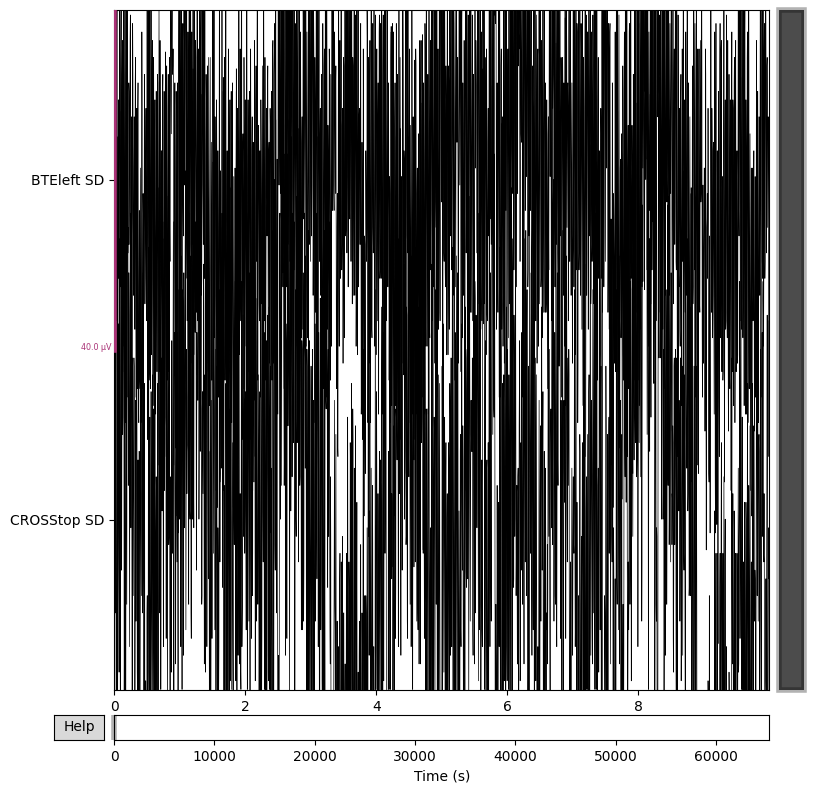

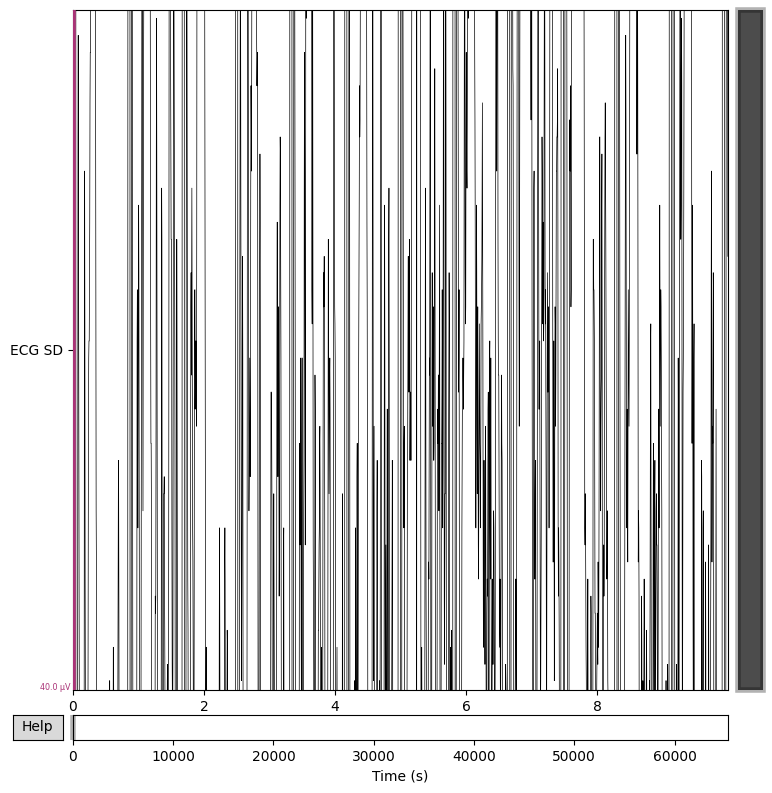

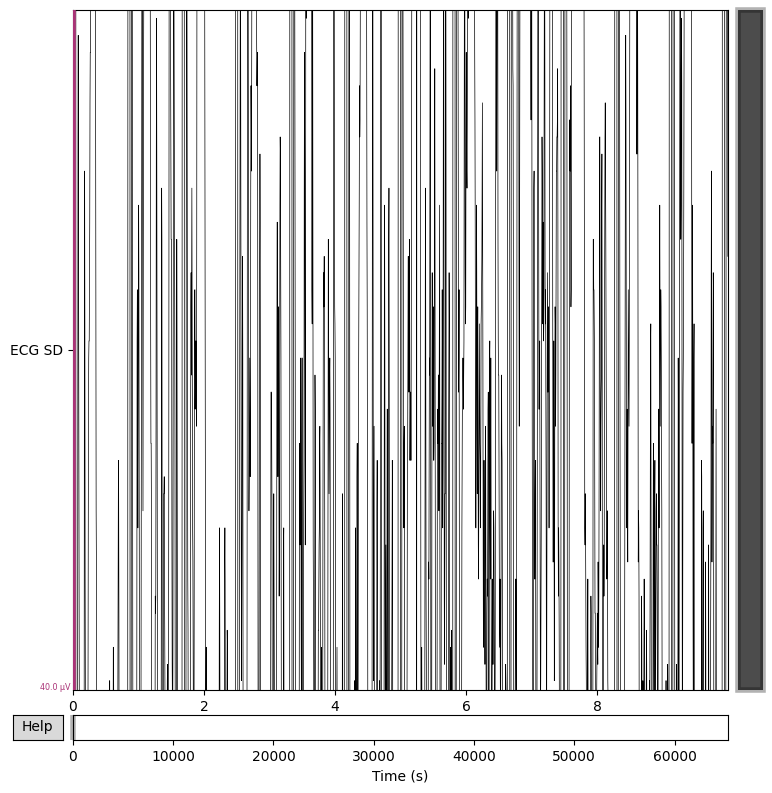

In [ ]:
# visualize EEG and ECG for one patient, one run
import glob, mne

eeg_path = "/content/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf"
ecg_path = "/content/ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-01_ecg.edf"

raw_eeg = mne.io.read_raw_edf(eeg_path, preload=True)
raw_ecg = mne.io.read_raw_edf(ecg_path, preload=True)

raw_eeg.plot(n_channels=20, duration=10)
raw_ecg.plot()


In [ ]:
eeg_data = raw_eeg.get_data()   # shape: (channels, timepoints)
eeg_sfreq = raw_eeg.info['sfreq']

print("Shape:", eeg_data.shape)
print("Sampling rate:", eeg_sfreq)

Shape: (2, 16721664)
Sampling rate: 256.0


In [ ]:
# load .edf windows for both EEG and ECG

import numpy as np
import mne

def load_edf_windows(
    edf_path: str,
    picks=None,                 # list of channel names OR None to infer
    window_sec: float = 10.0,
    overlap_sec: float = 5.0,
    resample_hz: float | None = 256.0,   # set None to keep original
    preload: bool = True,
    verbose: bool = False
):
    raw = mne.io.read_raw_edf(edf_path, preload=preload, verbose=verbose)

    # If channel picks not provided, keep all channels
    if picks is None:
        picks_idx = mne.pick_types(raw.info, eeg=True, ecg=True, emg=True, misc=True, stim=False, exclude=[])
    else:
        picks_idx = mne.pick_channels(raw.ch_names, include=picks)

    raw_pick = raw.copy().pick(picks_idx)

    # Resample for consistency (recommended for feature extraction)
    if resample_hz is not None:
        raw_pick.resample(resample_hz)

    data = raw_pick.get_data()  # shape: (n_channels, n_timepoints)
    sfreq = raw_pick.info["sfreq"]

    win_samp = int(window_sec * sfreq)
    hop_samp = int((window_sec - overlap_sec) * sfreq)
    if hop_samp <= 0:
        raise ValueError("overlap_sec must be < window_sec")

    n_ch, n_t = data.shape
    starts = np.arange(0, n_t - win_samp + 1, hop_samp)

    X = np.stack([data[:, s:s+win_samp] for s in starts], axis=0)
    # X shape: (n_windows, n_channels, win_samp)

    return X, sfreq, raw_pick.ch_names


In [ ]:
# FEATURIZING EEG

import numpy as np
from scipy.signal import welch

def bandpower(x, sfreq, fmin, fmax):
    freqs, psd = welch(x, sfreq, nperseg=sfreq*2)
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return np.trapz(psd[idx], freqs[idx])

def featurize_windows(X, sfreq, modality="eeg"):
    """
    X shape: (n_windows, n_channels, n_samples)
    Returns:
        F  -> (n_windows, n_features)
        feature_names -> list of strings
    """

    n_windows, n_channels, _ = X.shape
    features = []
    feature_names = []

    for w in range(n_windows):
        window_feats = []

        for ch in range(n_channels):
            sig = X[w, ch, :]

            # --- Basic time features ---
            mean = np.mean(sig)
            std = np.std(sig)
            rms = np.sqrt(np.mean(sig**2))
            skew = np.mean((sig - mean)**3) / (std**3 + 1e-8)

            window_feats.extend([mean, std, rms, skew])

            if w == 0:
                feature_names.extend([
                    f"ch{ch}_mean",
                    f"ch{ch}_std",
                    f"ch{ch}_rms",
                    f"ch{ch}_skew"
                ])

            # --- EEG frequency bands ---
            if modality == "eeg":
                delta = bandpower(sig, sfreq, 0.5, 4)
                theta = bandpower(sig, sfreq, 4, 8)
                alpha = bandpower(sig, sfreq, 8, 13)
                beta  = bandpower(sig, sfreq, 13, 30)
                gamma = bandpower(sig, sfreq, 30, 45)

                window_feats.extend([delta, theta, alpha, beta, gamma])

                if w == 0:
                    feature_names.extend([
                        f"ch{ch}_delta",
                        f"ch{ch}_theta",
                        f"ch{ch}_alpha",
                        f"ch{ch}_beta",
                        f"ch{ch}_gamma"
                    ])

        features.append(window_feats)

    F = np.array(features)
    return F, feature_names


In [ ]:
# FEATURIZING ECG

from scipy.signal import find_peaks

def featurize_ecg_windows(X, sfreq):
    n_windows, n_channels, _ = X.shape
    features = []
    feature_names = []

    for w in range(n_windows):
        window_feats = []

        # Assume single ECG channel
        sig = X[w, 0, :]

        mean = np.mean(sig)
        std = np.std(sig)
        rms = np.sqrt(np.mean(sig**2))

        peaks, _ = find_peaks(sig, distance=sfreq*0.4)
        hr = len(peaks) * (60 / (len(sig)/sfreq))

        window_feats.extend([mean, std, rms, hr])

        if w == 0:
            feature_names.extend([
                "ecg_mean",
                "ecg_std",
                "ecg_rms",
                "ecg_heart_rate"
            ])

        features.append(window_feats)

    F = np.array(features)
    return F, feature_names


In [ ]:
# combine both EEG and ECG featurized vectors

def combine_modalities_features(F_eeg, names_eeg, F_ecg, names_ecg):
    n = min(F_eeg.shape[0], F_ecg.shape[0])
    F = np.concatenate([F_eeg[:n], F_ecg[:n]], axis=1)
    names = names_eeg + names_ecg
    return F, names


In [ ]:
import os, re

def extract_run_id(path):
    m = re.search(r'run-(\d+)', os.path.basename(path))
    return int(m.group(1)) if m else None


In [ ]:
# y-labeling (seizure presence)

import pandas as pd
import numpy as np

def label_windows_from_events(events_path, window_starts, window_sec):
    """
    Returns binary labels per window.

    events_path: path to *_events.tsv
    window_starts: array of window start times (seconds)
    window_sec: window length (seconds)
    """

    events = pd.read_csv(events_path, sep="\t")

    # Only keep seizure rows (eventType starting with 'sz')
    # in the dataset, there are more than 100 classifications, so for simplicity
    # we just group by "sz"
    seizure_events = events[events["eventType"].str.startswith("sz", na=False)]

    labels = np.zeros(len(window_starts), dtype=int)

    for _, row in seizure_events.iterrows():
        sz_start = row["onset"]
        sz_end = row["onset"] + row["duration"]

        for i, w_start in enumerate(window_starts):
            w_end = w_start + window_sec

            # overlap condition
            if (w_start < sz_end) and (w_end > sz_start):
                labels[i] = 1

    return labels

In [ ]:
import glob
import numpy as np

BASE = "/content/ds005873"
SUBJECTS = ["sub-001", "sub-002", "sub-003"]
SESSION = "ses-01"

F_list = []
meta_list = []   # store (subject, run, window_idx, t0_sec)
Y_list = []

for sub in SUBJECTS:
    # find all EEG runs for that subject
    eeg_glob = f"{BASE}/{sub}/{SESSION}/eeg/*_eeg.edf"
    eeg_paths = sorted(glob.glob(eeg_glob))

    print(sub, "EEG runs found:", len(eeg_paths))

    for eeg_path in eeg_paths:
        run_id = extract_run_id(eeg_path)

        # matching ECG path (same basename pattern, just _ecg.edf and folder ecg)
        ecg_path = eeg_path.replace("/eeg/", "/ecg/").replace("_eeg.edf", "_ecg.edf")

        # skip if ECG missing
        if not os.path.exists(ecg_path):
            print("  missing ECG for", os.path.basename(eeg_path))
            continue

        # EEG
        X_eeg, sfreq_eeg, eeg_chs = load_edf_windows(
            eeg_path,
            window_sec=10,
            overlap_sec=5,
            resample_hz=256,   # or None
        )
        F_eeg, names_eeg = featurize_windows(X_eeg, sfreq_eeg, modality="eeg")

        # ECG
        X_ecg, sfreq_ecg, ecg_chs = load_edf_windows(
            ecg_path,
            window_sec=10,
            overlap_sec=5,
            resample_hz=256,   # or None
        )
        F_ecg, names_ecg = featurize_windows(X_ecg, sfreq_ecg, modality="ecg")

        # combine
        F_both, names_both = combine_modalities_features(F_eeg, names_eeg, F_ecg, names_ecg)  # (#windows, #feat_eeg + #feat_ecg)

        # store features
        F_list.append(F_both)

        # metadata
        nW = F_both.shape[0]
        step = 10 - 5
        t0 = np.arange(nW) * step

        events_path = eeg_path.replace("_eeg.edf", "_events.tsv")

        y_run = label_windows_from_events(
            events_path,
            window_starts=t0,
            window_sec=10
        )

        Y_list.append(y_run)


        meta_list.extend([
            (sub, run_id, i, float(t0[i]))
            for i in range(nW)
        ])

        print(f"  run {run_id}: windows={nW}, feats={F_both.shape[1]}")

# final stack
F_all = np.vstack(F_list)
Y_all = np.concatenate(Y_list)

print("Labels shape:", Y_all.shape)
print("Seizure windows:", Y_all.sum())

print("\nFINAL:", F_all.shape, " (windows_total, features_total)")
print("Number of feature columns:", len(names_both))


sub-001 EEG runs found: 9
Sampling frequency of the instance is already 256.0, returning unmodified.


/tmp/ipython-input-804781281.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])


Sampling frequency of the instance is already 256.0, returning unmodified.
  run 1: windows=13062, feats=22
Sampling frequency of the instance is already 256.0, returning unmodified.


/tmp/ipython-input-804781281.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])


Sampling frequency of the instance is already 256.0, returning unmodified.
  run 2: windows=3962, feats=22
Sampling frequency of the instance is already 256.0, returning unmodified.


...

Sampling frequency of the instance is already 256.0, returning unmodified.
  run 8: windows=15819, feats=22
Sampling frequency of the instance is already 256.0, returning unmodified.


/tmp/ipython-input-804781281.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])


Sampling frequency of the instance is already 256.0, returning unmodified.
  run 9: windows=1379, feats=22
Sampling frequency of the instance is already 256.0, returning unmodified.


/tmp/ipython-input-804781281.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])


Sampling frequency of the instance is already 256.0, returning unmodified.
  run 10: windows=15642, feats=22
Labels shape: (230839,)
Seizure windows: 473

FINAL: (230839, 22)  (windows_total, features_total)
Number of feature columns: 22


In [ ]:
import pandas as pd

meta_df = pd.DataFrame(meta_list, columns=["subject", "run", "window_idx", "t0_sec"])
print(meta_df.head())

print(names_both)

   subject  run  window_idx  t0_sec
0  sub-001    1           0     0.0
1  sub-001    1           1     5.0
2  sub-001    1           2    10.0
3  sub-001    1           3    15.0
4  sub-001    1           4    20.0
['ch0_mean', 'ch0_std', 'ch0_rms', 'ch0_skew', 'ch0_delta', 'ch0_theta', 'ch0_alpha', 'ch0_beta', 'ch0_gamma', 'ch1_mean', 'ch1_std', 'ch1_rms', 'ch1_skew', 'ch1_delta', 'ch1_theta', 'ch1_alpha', 'ch1_beta', 'ch1_gamma', 'ch0_mean', 'ch0_std', 'ch0_rms', 'ch0_skew']


(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use different distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [ ]:
# Packages (feel free to include more if needed)!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

# Data Distribution

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


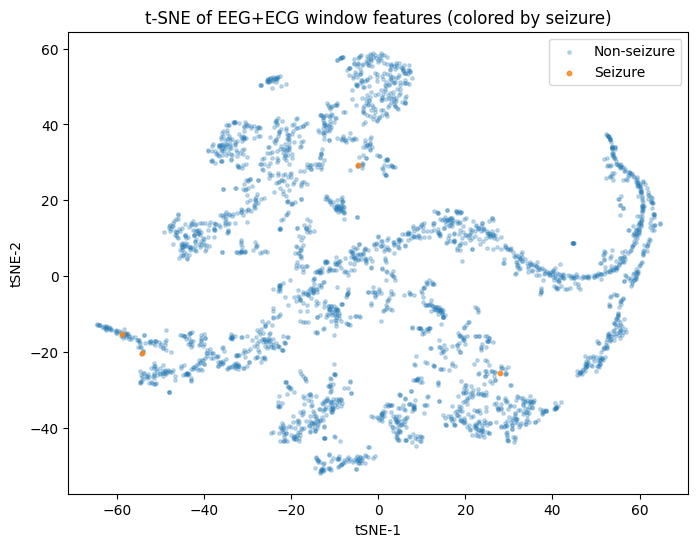

In [ ]:
def visualize_data_distribution(data, y_labels,
                                perplexity = 30, n_iter = 1000, title="t-SNE"):
  """
  Visualizes the distribution of a specified feature in a DataFrame.

  Args:
      data (np.array): The dataset that you plan on using as a 2D representation.
  """
  tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    n_iter=n_iter,
    init="pca",
    learning_rate="auto",
    random_state=0,
  )
  Z = tsne.fit_transform(data)

  plt.figure(figsize=(8,6))
  plt.scatter(Z[y_labels==0, 0], Z[y_labels==0, 1], s=6, alpha=0.25, label="Non-seizure")
  plt.scatter(Z[y_labels==1, 0], Z[y_labels==1, 1], s=10, alpha=0.8, label="Seizure")
  plt.legend()
  plt.title("t-SNE of EEG+ECG window features (colored by seizure)")
  plt.xlabel("tSNE-1")
  plt.ylabel("tSNE-2")
  plt.show()


max_points = 3000  # or even 2000

idx = np.random.choice(len(F_all), max_points, replace=False)

F_sub = F_all[idx]
Y_sub = Y_all[idx]


Z = visualize_data_distribution(
    F_sub, Y_sub,
    perplexity=30,
    n_iter=1000,
    title="sub-001 EEG+ECG windows (unlabeled)"
)

# Samples

Here, instead of the function given, I am using plotting to explore a few different questions through t-SNE.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


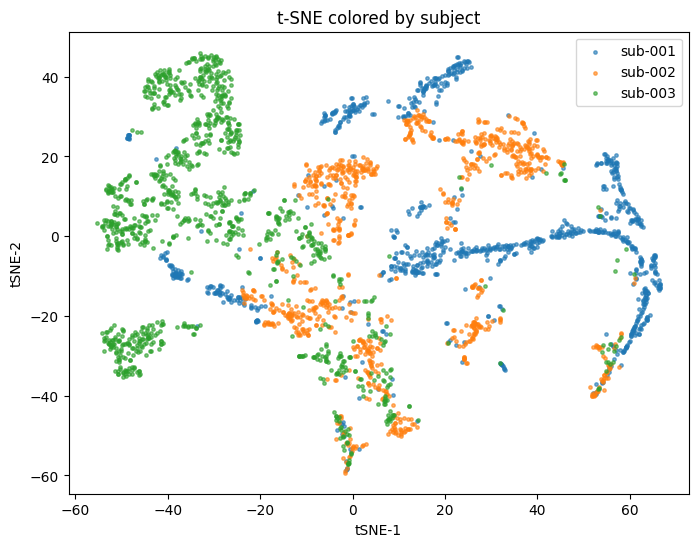

In [ ]:
# First question: does this data cluster by patient identity?
# this would make it hard for generalization

import numpy as np
from sklearn.manifold import TSNE

def tsne_embed(F, max_points=3000, random_state=0, perplexity=30, n_iter=1000):
    N = F.shape[0]
    rng = np.random.default_rng(random_state)
    idx = rng.choice(N, size=min(max_points, N), replace=False)

    perp = min(perplexity, max(5, (len(idx)-1)//3))
    Z = TSNE(n_components=2, perplexity=perp, n_iter=n_iter,
             init="pca", learning_rate="auto", random_state=random_state).fit_transform(F[idx])

    return Z, idx

Z, idx = tsne_embed(F_all)

import matplotlib.pyplot as plt

subjects = np.array([m[0] for m in meta_list])[idx]

plt.figure(figsize=(8,6))
for s in np.unique(subjects):
    mask = subjects == s
    plt.scatter(Z[mask,0], Z[mask,1], s=6, alpha=0.6, label=s)
plt.legend()
plt.title("t-SNE colored by subject")
plt.xlabel("tSNE-1"); plt.ylabel("tSNE-2")
plt.show()



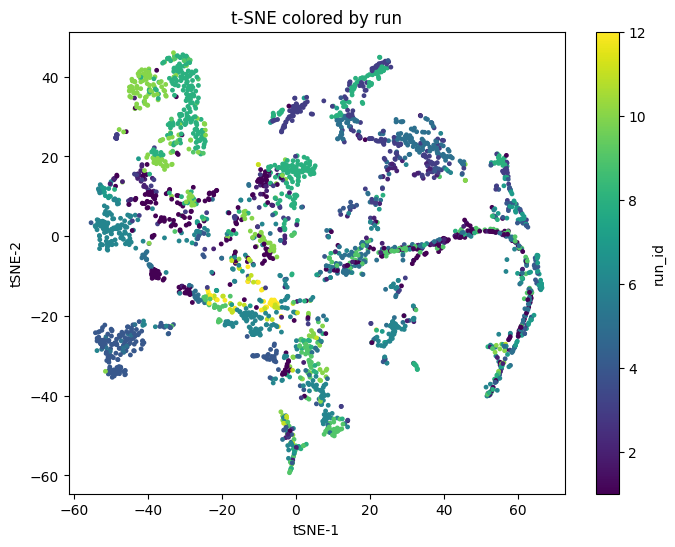

In [ ]:
# do runs drift, or do they also cluster together?
runs = np.array([m[1] for m in meta_list])[idx]

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=runs, s=6)
plt.colorbar(label="run_id")
plt.title("t-SNE colored by run")
plt.xlabel("tSNE-1"); plt.ylabel("tSNE-2")
plt.show()


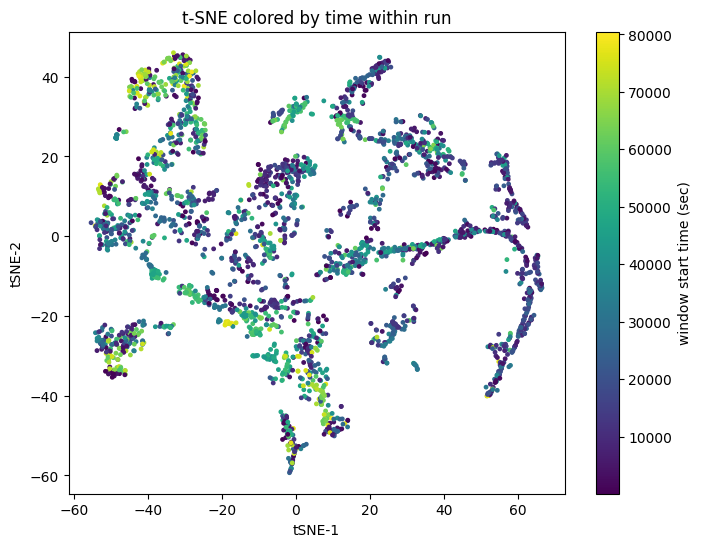

In [ ]:
# does the embedding vary over time
# (sleep/wake cycles, baseline drift, long-term changes)?

t0 = np.array([m[3] for m in meta_list])[idx]

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=t0, s=6)
plt.colorbar(label="window start time (sec)")
plt.title("t-SNE colored by time within run")
plt.xlabel("tSNE-1"); plt.ylabel("tSNE-2")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


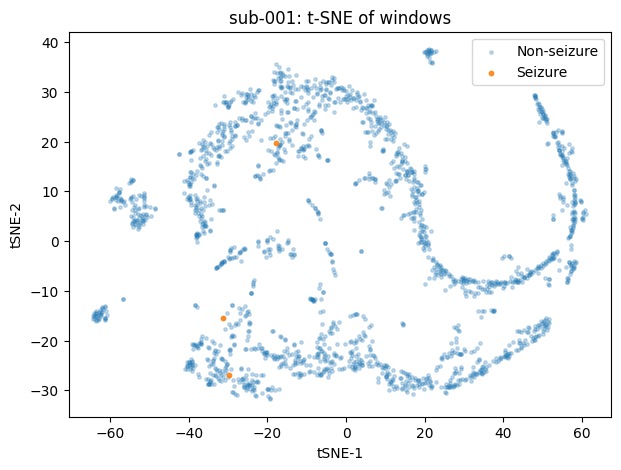

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


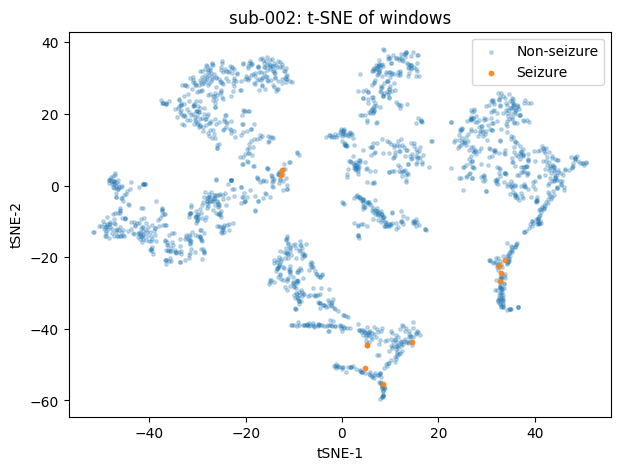

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


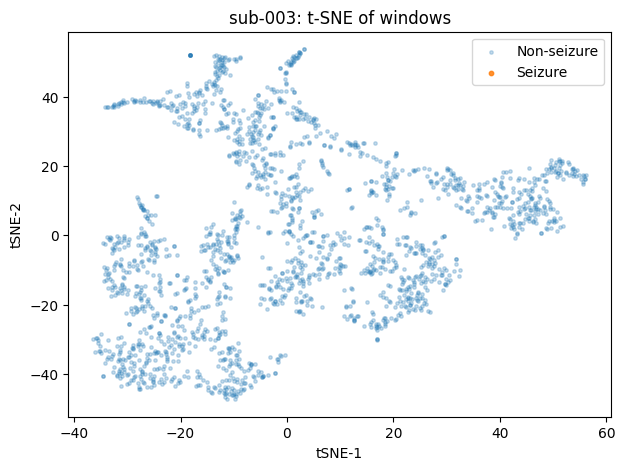

In [ ]:
# plotting t-sne for each patient
# question - does seizure separate within a single person?
meta = np.array(meta_list, dtype=object)
subj_all = meta[:,0]

for s in ["sub-001","sub-002","sub-003"]:
    mask = subj_all == s
    if mask.sum() < 200:
        continue
    Z_s, idx_s = tsne_embed(F_all[mask], max_points=2000, random_state=0)
    y_s = np.array(Y_all)[mask][idx_s] if "Y_all" in globals() else None

    plt.figure(figsize=(7,5))
    if y_s is None:
        plt.scatter(Z_s[:,0], Z_s[:,1], s=6)
    else:
        plt.scatter(Z_s[y_s==0,0], Z_s[y_s==0,1], s=6, alpha=0.25, label="Non-seizure")
        plt.scatter(Z_s[y_s==1,0], Z_s[y_s==1,1], s=10, alpha=0.85, label="Seizure")
        plt.legend()
    plt.title(f"{s}: t-SNE of windows")
    plt.xlabel("tSNE-1"); plt.ylabel("tSNE-2")
    plt.show()


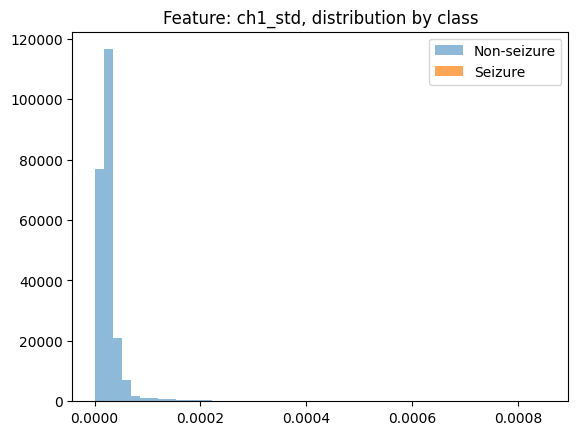

np.float64(0.0020490471714051787)

In [ ]:
import matplotlib.pyplot as plt

feat_idx = 10  # change to explore diff features
vals = F_all[:, feat_idx]
y = np.array(Y_all)

plt.hist(vals[y==0], bins=50, alpha=0.5, label="Non-seizure")
plt.hist(vals[y==1], bins=50, alpha=0.7, label="Seizure")
plt.legend()
plt.title(f"Feature: {names_both[feat_idx]}, distribution by class")
plt.show()


frac_sz = Y_all.mean()
frac_sz

# Input Distribution

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?

**A:**
  I plan to use the precision, recall, F1 score, and AUPRC (the precision-recall curve). These metrics better handle when there are very few positive (seizure-positive) data points. The F1 score is the harmonic mean between precision and recall, which focuses on how many true positives are predicted compared to total predicted positives and false negative predictions. In the case of healthcare data, being able to predict a positive seizure data point is a lot more important that being able to predict a negative seizure data point. In this case, there are significantly more negative points, and clinically it is usually more relevant to know when a patient is having or about to have a seizure.


2. Are there any other metrics that could be used here or that you considered?
  
  **A:** The Brier score is another metric commonly used in ML models that measures accuracy. However, this score doesn't do well with very few positive examples, so it wouldn't be as appropriate in this situation. The ROC-AUC is also a commonly used metric, but the false positive rate can look deceptively small. Even if the precision is bad, the ROC-AUC value may be high.

3. List out the pros and cons of the evaluation metrics you decided to go with.

  **A:** Some pros of the precision and recall are that they focus on the proportion of correctly identified true positives. In our case, true positives are rare and very few, so the precision and recall values are very meaningful (compared to the accuracy, which is easily inflated because the number of true negatives will be very large compared to the number of true positives).
  Some cons of the precision and recall are that they are threshold-depenedent.
  Depending on the classification model I use, the choice of threshold may affect these values.
  Some pros of the AUPRC is that it is sensitive to false positives and reflects performance on the positive class. The F1 score focuses on true positive predictions, which is helpful in the setting of healthcare data.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, average_precision_score

def evaluation_metric(predictions, ground_truths):
  # Convert to numpy arrays to ensure compatibility with sklearn metrics
  predictions = np.array(predictions)
  ground_truths = np.array(ground_truths)

  if len(ground_truths) == 0:
    raise ValueError("Issue reading ground truths/No ground truths provided!")

  # Accuracy
  accuracy = accuracy_score(ground_truths, predictions)

  # Precision, Recall, F1-Score (for binary classification, 'pos_label=1' assumes 1 is the positive class)
  # Use zero_division=0 to set precision/recall/f1 to 0 if there are no true positive predictions or ground truths respectively
  precision = precision_score(ground_truths, predictions, pos_label=1, zero_division=0)
  recall = recall_score(ground_truths, predictions, pos_label=1, zero_division=0)
  f1 = f1_score(ground_truths, predictions, pos_label=1, zero_division=0)

  # AUPRC (Area Under the Precision-Recall Curve)
  # For binary predictions, y_score is typically probability scores. If only hard predictions are available,
  # average_precision_score will treat them as scores.
  auprc = average_precision_score(ground_truths, predictions)

  return {
      "accuracy": accuracy,
      "precision": precision,
      "recall": recall,
      "f1_score": f1,
      "auprc": auprc
  }

(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

**A:** Classify the sentiment of the following restaurant review into one string in this list ['positive', 'negative', or 'neutral']. Review: "This place stinks, the service was awful and the food was not cooked. I will never come back here!" Sentiment:""

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

**A:** Classify each image in this dataset as one of  this list of emotions: ['angry', 'sad', 'happy'], dependent on the emotion of the person in the image. Choose and return only one emotion that encapsulates the person's emotion.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

**A:** Label the name of the subject with a single string. Additionally, label the location they are going to based on the input description. This label should one place, although this place may include one or more words. Lastly, return the label of their planned activity, which is a string containing one or more words. Please place these three values in a JSON formatted file, with the person name, then the location, then the planned activity.

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [ ]:
# BONUS CODE HERE


(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.

The idea of feature extraction was most interesting to me. I have learned about data pre-processing and input before, but I didn't realize how challenging it is in a real-world, actual project, to deal with large amounts of data. For me, extracting features from the EEG and ECG data first was the most realistic option for my setup, instead of working entirely with the raw data. It made me think carefully about which features I wanted to extract, because each additional feature I used added a significant amount of time to the processing time. It also required previous domain knowledge about what features were best, but in this case seemed to be my best option.

2. A challenging aspect that you did not expect to deal with and what insights you used to address it.

I faced a lot of challenging just accessing the data, which was linked as symlinks in a github repository. I haven't had experience accessing symlinks, and I constantly faced issues where the data seemed downloaded but my code couldn't actually find the files I was referencing. I learned a lot about datalad and accessing public datasets. There was a lot of useful information online about accessing/downloading the data. In terms of insights, the constraint of dealing with significantly more data made me be more conscious about running chunks of code, because I had to double check everything was right with a smaller case or through careful debugging. Otherwise, it cost me a lot of time.

3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

I think this dataset is overall pretty strong. It contains many hours of EEG and ECG for the same patients, which are synced via the timestamps of the data. One downside is that there are relatively few seizure-positive windows vs. non-seizure windows (about 0.2% of the windows are seizures), which I think is a downside but reflects the reality of how common seizures are. This class imbalance may lead to a false sense of model performance, because the model can classify most events as non-seizure and achieve a high accuracy rate. I will be sure to note this in my analysis of the ML models I use this data on.

There is no specific right answer we are looking for, answer how you think!